# Model

In [593]:
from topological_insulator import Problem, ModelOptions, Geometry, TightBindingEdge

data_path = "../../topological_insulator/data/"
file_name = "honeycomb.json"

problem = Problem(data_path=data_path, file_name=file_name)

In [594]:
import numpy as np
from sympy.physics.quantum.cg import CG
def _clebsch_gordan(tb:TightBindingEdge):
        tb.CG_coefficients = {}
        j_2 = 1/2
        m_2 = np.arange(-j_2, j_2 + 1, 1)
        for j_1 in [0, 1]:          
            m_1 = np.arange(-j_1, j_1 + 1, 1)
            j_3 = j_1 + j_2
            m_3 = np.arange(-j_3, j_3 + 1, 1)
            for i, m_j in enumerate(m_3):
                for m_l in m_1:
                    # if m_l in [1, -1]:
                    #     continue # p_x & p_y 
                    # if m_l in [0]:
                    #     continue # s & p_z
                    # if j_1 == 1:
                    #     continue # s
                    # if m_l in [0] and j_1 == 1:
                    #     continue # p_z
                    for m_s in m_2:
                        state = f"|{j_1},{m_l};{j_2},{m_s}>"
                        if (m_l + m_s) != m_j:
                            continue
                        tb.CG_coefficients[state] = CG(j_1, m_l, j_2, m_s, j_3, m_j).doit()

In [595]:
import numpy as np
SO_coupling = 0.4
orbitals = ['s', 'p_x', 'p_y', 'p_z']

In [596]:
sub_1, sub_2 = ["A", "B"], ["B", "A"]
for sub_label, nn_label in zip(sub_1, sub_2):
    parser = getattr(problem.cell_parser.eigenvalues, sub_label).value
    parser["nn_hopping"][nn_label]["t_ss_sigma"] = -np.sqrt(2)
    parser["nn_hopping"][nn_label]["t_sp_sigma"] = 1
    parser["nn_hopping"][nn_label]["t_pp_sigma"] = 1
    parser["nn_hopping"][nn_label]["t_pp_pi"] = -2
    parser["SO_coupling"][sub_label]["lambda_pp"] = SO_coupling

In [597]:
location = "edge"

# Setup
problem.model_options = ModelOptions(10, 200, location, "reduced")
problem.geometry = Geometry(model_options=problem.model_options, cell_parser=problem.cell_parser)
problem.geometry.build_lattice()

problem.hamiltonian[location]["tight_binding"] = TightBindingEdge(
                model_options=problem.model_options, cell_parser=problem.cell_parser)
tight_binding:TightBindingEdge = problem.hamiltonian[location]["tight_binding"]
tight_binding.orbitals = orbitals
tight_binding.n_orbitals = len(orbitals)

Building Geometry...
Geometry - Done.


In [598]:
problem.model_options.solve_connectivity = False

In [599]:
_clebsch_gordan(tight_binding)
tight_binding.CG_coefficients

{'|0,0;0.5,-0.5>': 0.707106781186548*sqrt(2),
 '|0,0;0.5,0.5>': 0.707106781186548*sqrt(2),
 '|1,-1;0.5,-0.5>': 1.00000000000000,
 '|1,-1;0.5,0.5>': 0.333333333333333*sqrt(3),
 '|1,0;0.5,-0.5>': 0.333333333333333*sqrt(6),
 '|1,0;0.5,0.5>': 0.333333333333333*sqrt(6),
 '|1,1;0.5,-0.5>': 0.333333333333333*sqrt(3),
 '|1,1;0.5,0.5>': 1.00000000000000}

In [600]:
tight_binding.build_hamiltonian(geometry=problem.geometry)

Building 'Edge' Hamiltonian...
'Edge' Hamiltonian - Done.


In [601]:
tight_binding.sublattice_idxs = np.delete(tight_binding.sublattice_idxs, [0, -1])

In [602]:
problem.run(
    H_type="reciprocal_space"
)

Calculating 'Edge' eigenvalues...
'Edge' Eigenvalues - Done.


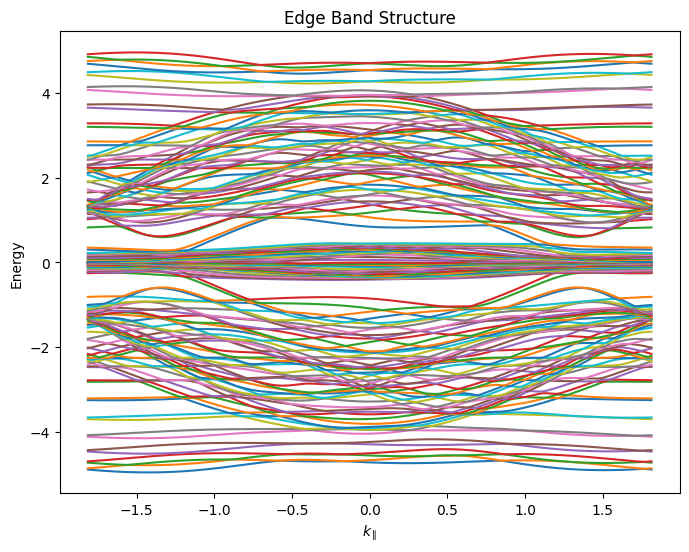

In [603]:
problem.plot(plot_type="dispersion", location=location)

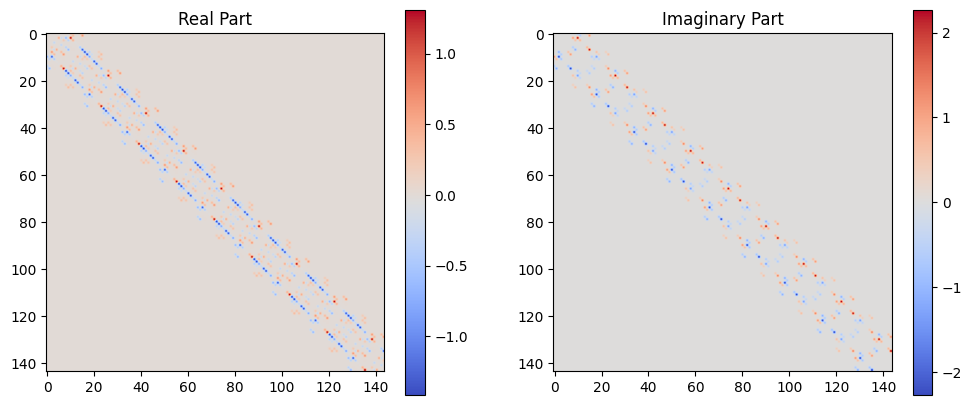

In [604]:
tb = problem.hamiltonian["edge"]["tight_binding"]
g = problem.geometry
k = g.k_edge[1]
H_k = tb._fourier_transform(g, k)
tb._visualise_matrix(H_k)